Total images found: 25000
Images selected: 2000

Extracting HOG + Hu Moments features...
Processed 100/2000
Processed 200/2000
Processed 300/2000
Processed 400/2000
Processed 500/2000
Processed 600/2000
Processed 700/2000
Processed 800/2000
Processed 900/2000
Processed 1000/2000
Processed 1100/2000
Processed 1200/2000
Processed 1300/2000
Processed 1400/2000
Processed 1500/2000
Processed 1600/2000
Processed 1700/2000
Processed 1800/2000
Processed 1900/2000
Processed 2000/2000

Feature Extraction Finished
Number of samples: 2000
Number of features: 1771
HOG + Hu feature shape: (2000, 1771)

Train / Test Split
Training samples: 1600
Testing samples: 400

5-Fold Cross Validation

========== Fold 1 ==========
Fold 1 Accuracy: 70.94%

========== Fold 2 ==========
Fold 2 Accuracy: 71.56%

========== Fold 3 ==========
Fold 3 Accuracy: 72.50%

========== Fold 4 ==========
Fold 4 Accuracy: 72.81%

========== Fold 5 ==========
Fold 5 Accuracy: 70.94%

Cross Validation Results
Fold 1: 70.94%
Fold 

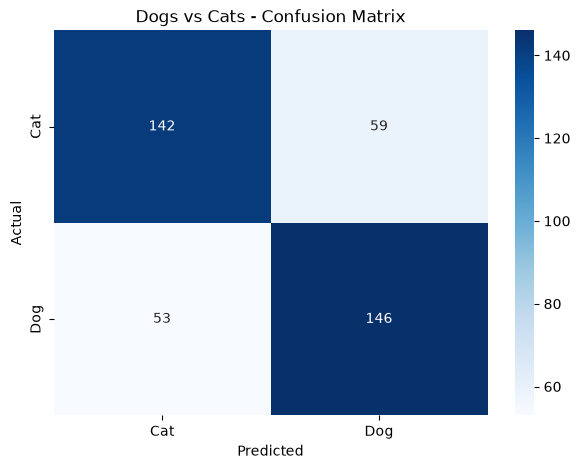


10 Random Test Images


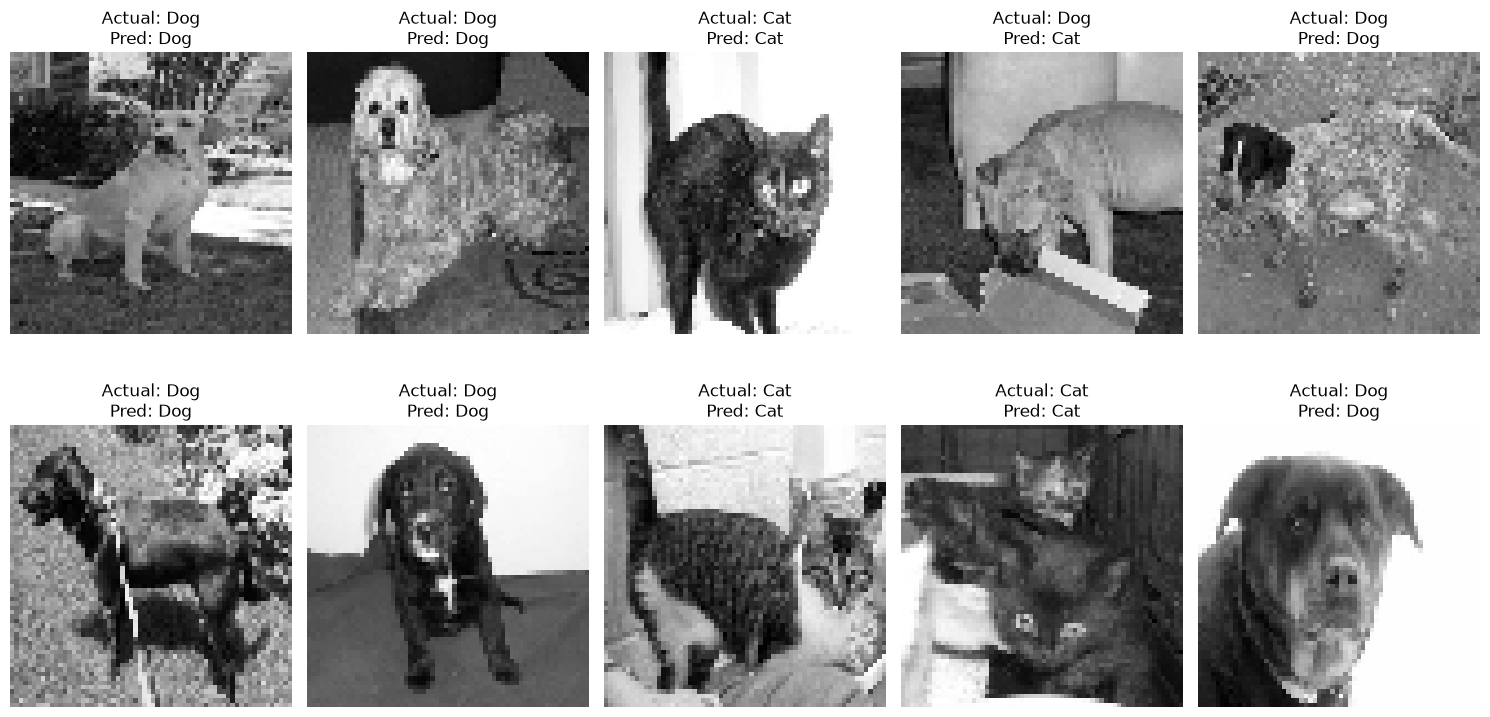


Test results saved to: dogs_cats_test_results.csv
Cross Validation results saved to: dogs_cats_cross_validation.csv

Model Saved
dogs_cats_hog_hu_ann_model.pkl
dogs_cats_hog_hu_scaler.pkl

FINAL SUMMARY
Dataset Images: 2000
Feature Count: 1771
Cross Validation Folds: 5
Mean CV Accuracy: 71.75%
CV Standard Deviation: 0.78%
Final Test Accuracy: 72.00%

Classification:
0 = Cat
1 = Dog

Done!


In [2]:

# ============================================================
# DOGS vs CATS
# HOG + Hu Moments + ANN
# 5-Fold Cross Validation
# ============================================================

import os
import cv2
import random
import joblib
import csv
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns


# ============================================================
# 1 - Dataset Path
# ============================================================

dataset_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\train\train"


# ============================================================
# 2 - Settings
# ============================================================

IMAGE_SIZE = (64, 64)
NUMBER_OF_IMAGES = 2000

random.seed(42)
np.random.seed(42)


# ============================================================
# 3 - Get Images
# ============================================================

all_images = []

for image_name in os.listdir(dataset_path):

    image_path = os.path.join(dataset_path, image_name)

    if image_name.lower().endswith((".jpg", ".jpeg", ".png")):

        if image_name.lower().startswith("cat"):
            label = 0

        elif image_name.lower().startswith("dog"):
            label = 1

        else:
            continue

        all_images.append((image_path, label))


print("Total images found:", len(all_images))


# ============================================================
# 4 - Randomly Select 2000 Images
# ============================================================

random.shuffle(all_images)

selected_images = all_images[:NUMBER_OF_IMAGES]

print("Images selected:", len(selected_images))


# ============================================================
# 5 - HOG + Hu Moments Feature Extraction
# ============================================================

features = []
labels = []
original_images = []


print("\nExtracting HOG + Hu Moments features...")


for index, (image_path, label) in enumerate(selected_images):

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        continue

    # Resize to 64x64
    image = cv2.resize(image, IMAGE_SIZE)

    # Save original processed image
    original_images.append(image.copy())

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    image_normalized = image / 255.0


    # --------------------------------------------------------
    # HOG
    # --------------------------------------------------------

    hog_features = hog(
        image_normalized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )


    # --------------------------------------------------------
    # Hu Moments
    # --------------------------------------------------------

    moments = cv2.moments(image)

    hu_moments = cv2.HuMoments(moments).flatten()


    # Log transform Hu Moments
    for i in range(len(hu_moments)):

        if hu_moments[i] != 0:

            hu_moments[i] = (
                -np.sign(hu_moments[i])
                * np.log10(abs(hu_moments[i]))
            )


    # --------------------------------------------------------
    # Combine HOG + Hu
    # --------------------------------------------------------

    combined_features = np.concatenate(
        [hog_features, hu_moments]
    )


    features.append(combined_features)
    labels.append(label)


    # Progress
    if (index + 1) % 100 == 0:

        print(
            f"Processed {index + 1}/{len(selected_images)}"
        )


# Convert to NumPy arrays

X = np.array(features)
y = np.array(labels)
original_images = np.array(original_images)


# ============================================================
# 6 - Information
# ============================================================

print("\n==========================================")
print("Feature Extraction Finished")
print("==========================================")

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("HOG + Hu feature shape:", X.shape)


# ============================================================
# 7 - Train / Test Split
# ============================================================

X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(
    X,
    y,
    original_images,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n==========================================")
print("Train / Test Split")
print("==========================================")

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 8 - ANN Function
# ============================================================

def create_ann():

    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=50,
        batch_size=128,
        random_state=42,
        verbose=False
    )

    return model


# ============================================================
# 9 - 5-Fold Cross Validation
# ============================================================

print("\n==========================================")
print("5-Fold Cross Validation")
print("==========================================")


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


fold_accuracies = []


for fold, (train_index, validation_index) in enumerate(
    skf.split(X_train, y_train),
    start=1
):

    print(f"\n========== Fold {fold} ==========")


    X_fold_train = X_train[train_index]
    X_fold_validation = X_train[validation_index]

    y_fold_train = y_train[train_index]
    y_fold_validation = y_train[validation_index]


    # --------------------------------------------------------
    # Pipeline
    # StandardScaler + ANN
    # --------------------------------------------------------

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ann", create_ann())
    ])


    # Train

    pipeline.fit(
        X_fold_train,
        y_fold_train
    )


    # Validation prediction

    y_fold_pred = pipeline.predict(
        X_fold_validation
    )


    # Accuracy

    fold_accuracy = accuracy_score(
        y_fold_validation,
        y_fold_pred
    )


    fold_accuracies.append(
        fold_accuracy
    )


    print(
        f"Fold {fold} Accuracy: "
        f"{fold_accuracy * 100:.2f}%"
    )


# ============================================================
# 10 - Cross Validation Results
# ============================================================

mean_cv_accuracy = np.mean(
    fold_accuracies
)

std_cv_accuracy = np.std(
    fold_accuracies
)


print("\n==========================================")
print("Cross Validation Results")
print("==========================================")


for i, accuracy in enumerate(
    fold_accuracies,
    start=1
):

    print(
        f"Fold {i}: "
        f"{accuracy * 100:.2f}%"
    )


print(
    f"\nMean Accuracy: "
    f"{mean_cv_accuracy * 100:.2f}%"
)


print(
    f"Standard Deviation: "
    f"{std_cv_accuracy * 100:.2f}%"
)


# ============================================================
# 11 - Train Final Model
# ============================================================

print("\n==========================================")
print("Training Final ANN Model")
print("==========================================")


# StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ANN

model = create_ann()


model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 12 - Test Prediction
# ============================================================

y_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 13 - Test Accuracy
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n==========================================")
print("Final Test Accuracy")
print("==========================================")


print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


# ============================================================
# 14 - Classification Report
# ============================================================

print("\n==========================================")
print("Classification Report")
print("==========================================")


print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)


# ============================================================
# 15 - Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Dogs vs Cats - Confusion Matrix"
)

plt.show()


# ============================================================
# 16 - Display 10 Random Test Images
# ============================================================

print("\n==========================================")
print("10 Random Test Images")
print("==========================================")


random_indices = random.sample(
    range(len(images_test)),
    10
)


plt.figure(figsize=(15, 8))


for i, index in enumerate(random_indices):

    plt.subplot(2, 5, i + 1)


    image = images_test[index]

    actual = y_test[index]

    predicted = y_pred[index]


    if actual == 0:
        actual_name = "Cat"
    else:
        actual_name = "Dog"


    if predicted == 0:
        predicted_name = "Cat"
    else:
        predicted_name = "Dog"


    plt.imshow(
        image,
        cmap="gray"
    )


    plt.title(
        f"Actual: {actual_name}\n"
        f"Pred: {predicted_name}"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# 17 - Save Test Results CSV
# ============================================================

test_results_file = "dogs_cats_test_results.csv"


with open(
    test_results_file,
    "w",
    newline=""
) as file:

    writer = csv.writer(file)

    writer.writerow([
        "Actual",
        "Predicted"
    ])


    for actual, predicted in zip(
        y_test,
        y_pred
    ):

        actual_name = (
            "Cat" if actual == 0
            else "Dog"
        )


        predicted_name = (
            "Cat" if predicted == 0
            else "Dog"
        )


        writer.writerow([
            actual_name,
            predicted_name
        ])


print(
    f"\nTest results saved to: "
    f"{test_results_file}"
)


# ============================================================
# 18 - Save Cross Validation Results
# ============================================================

cv_results_file = (
    "dogs_cats_cross_validation.csv"
)


with open(
    cv_results_file,
    "w",
    newline=""
) as file:

    writer = csv.writer(file)

    writer.writerow([
        "Fold",
        "Accuracy"
    ])


    for i, accuracy in enumerate(
        fold_accuracies,
        start=1
    ):

        writer.writerow([
            i,
            accuracy
        ])


    writer.writerow([
        "Mean",
        mean_cv_accuracy
    ])


    writer.writerow([
        "Standard Deviation",
        std_cv_accuracy
    ])


print(
    f"Cross Validation results saved to: "
    f"{cv_results_file}"
)


# ============================================================
# 19 - Save Model
# ============================================================

joblib.dump(
    model,
    "dogs_cats_hog_hu_ann_model.pkl"
)


joblib.dump(
    scaler,
    "dogs_cats_hog_hu_scaler.pkl"
)


print("\n==========================================")
print("Model Saved")
print("==========================================")


print(
    "dogs_cats_hog_hu_ann_model.pkl"
)

print(
    "dogs_cats_hog_hu_scaler.pkl"
)


# ============================================================
# 20 - Final Summary
# ============================================================

print("\n==========================================")
print("FINAL SUMMARY")
print("==========================================")


print(
    f"Dataset Images: {len(X)}"
)


print(
    f"Feature Count: {X.shape[1]}"
)


print(
    f"Cross Validation Folds: 5"
)


print(
    f"Mean CV Accuracy: "
    f"{mean_cv_accuracy * 100:.2f}%"
)


print(
    f"CV Standard Deviation: "
    f"{std_cv_accuracy * 100:.2f}%"
)


print(
    f"Final Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


print("\nClassification:")
print("0 = Cat")
print("1 = Dog")


print("\nDone!")

